# E-commerce Sales Analytics – Business Intelligence Project

**Author**: Narges  
**Date**: December 2025  
**Dataset**: Brazilian E-Commerce Public Dataset (Olist) from Kaggle

---

## Project Objective

This project analyzes 2 years of Brazilian e-commerce sales data to:
- Calculate key business KPIs (revenue, average order value, growth trends)
- Identify top-performing product categories and sellers
- Understand customer behavior and operational performance
- Demonstrate SQL and data analysis skills for portfolio

**Tools**: Python, pandas, matplotlib, seaborn, SQL

---


## 1. Import Libraries

Import necessary Python libraries for data manipulation, analysis, and visualization.


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Datasets

The Brazilian e-commerce dataset consists of 9 CSV files representing different aspects of the business:
- **customers**: Customer information
- **orders**: Order details and status
- **order_items**: Products in each order (price, shipping, seller)
- **order_payments**: Payment methods and amounts
- **order_reviews**: Customer reviews and ratings
- **products**: Product catalog
- **sellers**: Seller information
- **category_translation**: Product category names in English


In [ ]:


# Load all datasets
customers = pd.read_csv('../data/olist_customers_dataset.csv')
orders = pd.read_csv('../data/olist_orders_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
order_payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
category_translation = pd.read_csv('../data/product_category_name_translation.csv')




Dataset shapes:
Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Order Payments: (103886, 5)
Order Reviews: (99224, 7)
Products: (32951, 9)
Sellers: (3095, 4)
Category Translation: (71, 2)


### 2.1 Dataset Overview

Let's examine the size and structure of each table to understand the data volume.


In [ ]:
print("Dataset shapes:")
print(f"Customers: {customers.shape}")
print(f"Orders: {orders.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Order Payments: {order_payments.shape}")
print(f"Order Reviews: {order_reviews.shape}")
print(f"Products: {products.shape}")
print(f"Sellers: {sellers.shape}")
print(f"Category Translation: {category_translation.shape}")

## 3. Understand Data Relationships

Before analysis, we need to understand how tables connect (like a database schema):
- Each **order** can have multiple **items** (one-to-many)
- Each **order** can have multiple **payment** methods
- Orders link to **customers**, items link to **products** and **sellers**


In [23]:
# Look at the first few rows of each main table
print("=== ORDERS ===")
print(orders.head())
print("\n=== ORDER ITEMS ===")
print(order_items.head())
print("\n=== ORDER PAYMENTS ===")
print(order_payments.head())


=== ORDERS ===
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00   

### 3.1 Date Range and Order Status

Examine the time period covered by the data and the distribution of order statuses.


In [24]:
# Convert date columns
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

print(f"Date range: {orders['order_purchase_timestamp'].min()} to {orders['order_purchase_timestamp'].max()}")
print(f"\nTotal orders: {orders.shape[0]:,}")
print(f"\nOrder status distribution:")
print(orders['order_status'].value_counts())


Date range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18

Total orders: 99,441

Order status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [25]:
# Examine key columns to understand relationships
print("=== Table Relationships ===\n")

print("ORDERS table key columns:")
print(orders.columns.tolist())
print(f"\nUnique order_id: {orders['order_id'].nunique()}")
print(f"Unique customer_id: {orders['customer_id'].nunique()}")

print("\n\nORDER_ITEMS table key columns:")
print(order_items.columns.tolist())
print(f"\nUnique order_id: {order_items['order_id'].nunique()}")
print(f"Unique product_id: {order_items['product_id'].nunique()}")

print("\n\nORDER_PAYMENTS table key columns:")
print(order_payments.columns.tolist())

print("\n\nHow tables connect:")
print("- orders.order_id ← order_items.order_id (1 order has many items)")
print("- orders.order_id ← order_payments.order_id (1 order has many payments)")
print("- orders.customer_id → customers.customer_id")
print("- order_items.product_id → products.product_id")
print("- order_items.seller_id → sellers.seller_id")


=== Table Relationships ===

ORDERS table key columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Unique order_id: 99441
Unique customer_id: 99441


ORDER_ITEMS table key columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Unique order_id: 98666
Unique product_id: 32951


ORDER_PAYMENTS table key columns:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


How tables connect:
- orders.order_id ← order_items.order_id (1 order has many items)
- orders.order_id ← order_payments.order_id (1 order has many payments)
- orders.customer_id → customers.customer_id
- order_items.product_id → products.product_id
- order_items.seller_id → sellers.seller_id


## 4. Key Performance Indicators (KPIs)

### 4.1 Total Revenue and Average Order Value

Calculate overall business performance metrics from delivered orders only.

**Business Questions**:
- What is the total revenue over the 2-year period?
- What is the average order value (AOV)?
- How much revenue comes from shipping vs products?


In [26]:
# Join orders with order_items and payments to calculate revenue
# Only include delivered orders
delivered_orders = orders[orders['order_status'] == 'delivered']

# Join with order_items to get item-level data
revenue_data = delivered_orders.merge(order_items, on='order_id', how='inner')

# Calculate total revenue
total_revenue = revenue_data['price'].sum()
total_freight = revenue_data['freight_value'].sum()
total_revenue_with_freight = total_revenue + total_freight

print(f"=== Revenue Summary ===")
print(f"Total Revenue (products only): ${total_revenue:,.2f}")
print(f"Total Freight Revenue: ${total_freight:,.2f}")
print(f"Total Revenue (with freight): ${total_revenue_with_freight:,.2f}")
print(f"\nNumber of delivered orders: {delivered_orders.shape[0]:,}")
print(f"Average Order Value (AOV): ${total_revenue_with_freight / delivered_orders.shape[0]:,.2f}")


=== Revenue Summary ===
Total Revenue (products only): $13,221,498.11
Total Freight Revenue: $2,198,275.64
Total Revenue (with freight): $15,419,773.75

Number of delivered orders: 96,478
Average Order Value (AOV): $159.83


### 4.2 Monthly Revenue Trend

Analyze how revenue changed over time to identify growth patterns and seasonality.

**Business Question**: Is the business growing or declining? Are there seasonal patterns?


C:\Users\narges\AppData\Local\Temp\ipykernel_16548\1820986567.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered_orders['order_month'] = pd.to_datetime(delivered_orders['order_purchase_timestamp']).dt.to_period('M')


=== Monthly Revenue ===
   order_month      price
11     2017-09  607399.67
12     2017-10  648247.65
13     2017-11  987765.37
14     2017-12  726033.19
15     2018-01  924645.00
16     2018-02  826437.13
17     2018-03  953356.25
18     2018-04  973534.09
19     2018-05  977544.69
20     2018-06  856077.86
21     2018-07  867953.46
22     2018-08  838576.64


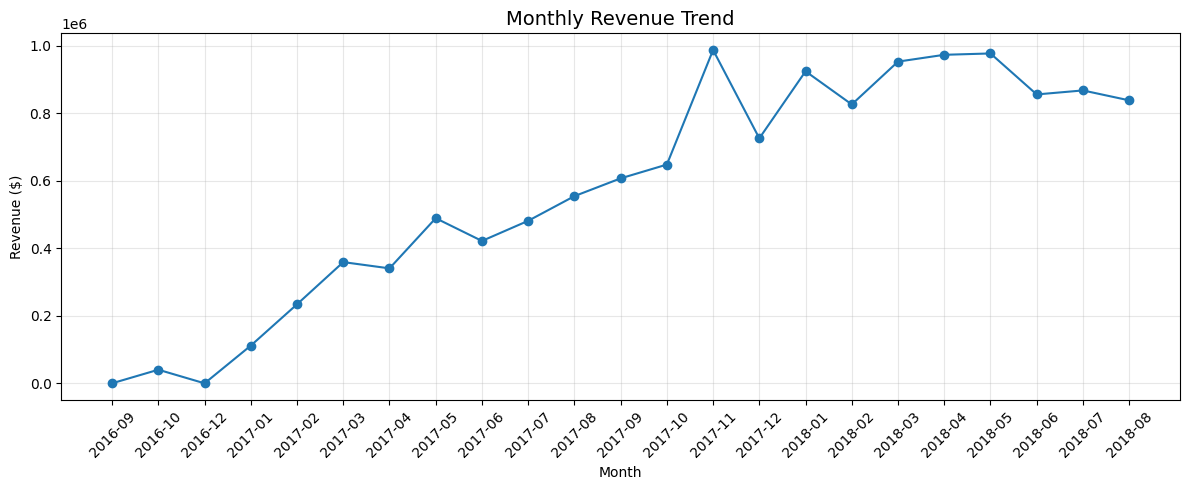

In [27]:
# Extract year-month from order date
delivered_orders['order_month'] = pd.to_datetime(delivered_orders['order_purchase_timestamp']).dt.to_period('M')

# Join with items and group by month
monthly_revenue = delivered_orders.merge(order_items, on='order_id') \
    .groupby('order_month')['price'].sum().reset_index()

monthly_revenue['order_month'] = monthly_revenue['order_month'].astype(str)

print("=== Monthly Revenue ===")
print(monthly_revenue.tail(12))  # Last 12 months

# Plot the trend
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue['order_month'], monthly_revenue['price'], marker='o')
plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 4.3 Top Product Categories

Identify which product categories generate the most revenue.

**Business Question**: Which product categories should the company focus on for marketing and inventory?


=== Top 10 Product Categories by Revenue ===
  product_category_name_english       price
0                 health_beauty  1258681.34
1                 watches_gifts  1205005.68
2                bed_bath_table  1036988.68
3                sports_leisure   988048.97
4         computers_accessories   911954.32
5               furniture_decor   729762.49
6                    cool_stuff   635290.85
7                    housewares   632248.66
8                          auto   592720.11
9                  garden_tools   485256.46


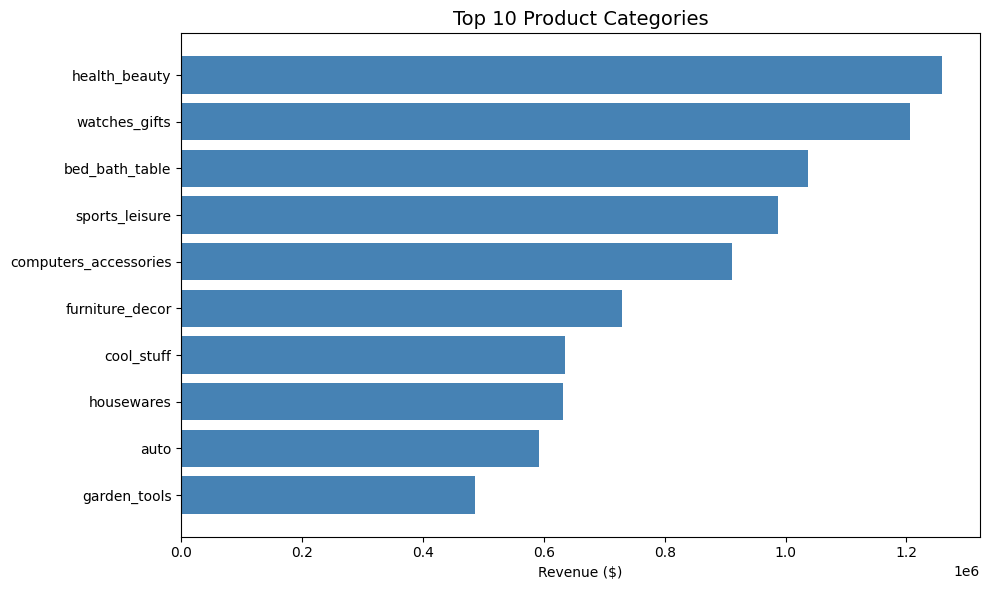

In [28]:
# Join order_items with products and category translation
category_revenue = order_items.merge(products, on='product_id', how='left') \
    .merge(category_translation, on='product_category_name', how='left')

# Group by category and calculate revenue
top_categories = category_revenue.groupby('product_category_name_english')['price'] \
    .sum().sort_values(ascending=False).head(10).reset_index()

print("=== Top 10 Product Categories by Revenue ===")
print(top_categories)

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(top_categories['product_category_name_english'], top_categories['price'], color='steelblue')
plt.xlabel('Revenue ($)')
plt.title('Top 10 Product Categories', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### 4.4 Customer Behavior Analysis

Calculate repeat purchase rate to understand customer loyalty.

**Business Question**: How many customers make repeat purchases?

**Note**: This dataset has anonymized customer IDs per order, so true repeat purchase tracking is limited.


In [29]:
# Calculate how many customers made repeat purchases
customer_orders = orders[orders['order_status'] == 'delivered'] \
    .groupby('customer_id')['order_id'].count().reset_index()
customer_orders.columns = ['customer_id', 'order_count']

total_customers = customer_orders.shape[0]
repeat_customers = customer_orders[customer_orders['order_count'] > 1].shape[0]
repeat_rate = (repeat_customers / total_customers) * 100

print(f"=== Customer Behavior ===")
print(f"Total unique customers: {total_customers:,}")
print(f"Customers with 1 order: {customer_orders[customer_orders['order_count'] == 1].shape[0]:,}")
print(f"Customers with 2+ orders (repeat): {repeat_customers:,}")
print(f"Repeat Purchase Rate: {repeat_rate:.2f}%")
print(f"\nMax orders by single customer: {customer_orders['order_count'].max()}")


=== Customer Behavior ===
Total unique customers: 96,478
Customers with 1 order: 96,478
Customers with 2+ orders (repeat): 0
Repeat Purchase Rate: 0.00%

Max orders by single customer: 1


=== Top 10 Sellers by Revenue ===
1. Seller 4869f7a5...: $229,472.63
2. Seller 53243585...: $222,776.05
3. Seller 4a3ca931...: $200,472.92
4. Seller fa1c13f2...: $194,042.03
5. Seller 7c67e144...: $187,923.89
6. Seller 7e93a43e...: $176,431.87
7. Seller da8622b1...: $160,236.57
8. Seller 7a67c85e...: $141,745.53
9. Seller 1025f0e2...: $138,968.55
10. Seller 955fee92...: $135,171.70


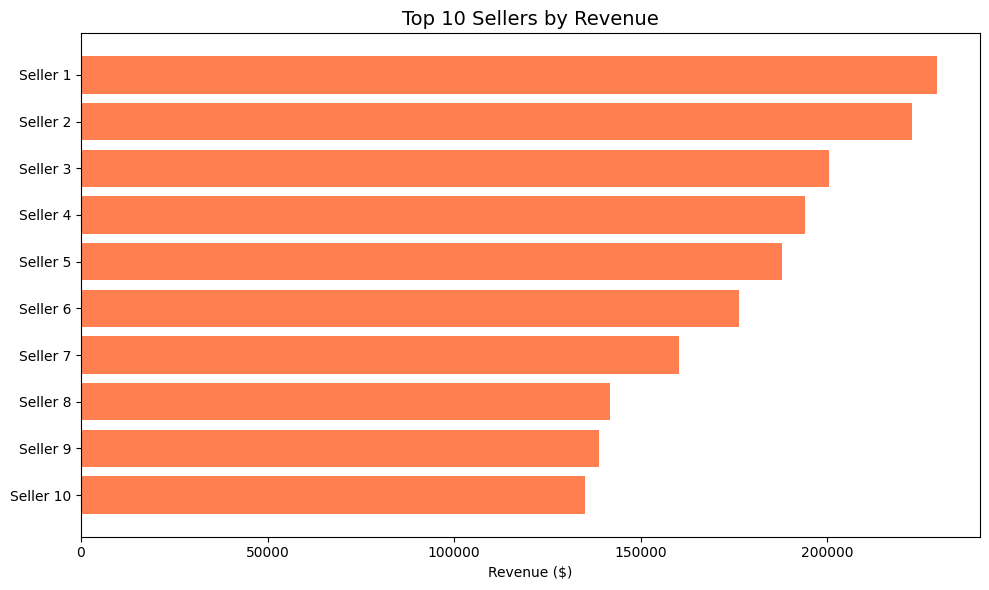

In [30]:
# Join order_items with seller info
seller_revenue = order_items.groupby('seller_id')['price'].sum() \
    .sort_values(ascending=False).head(10).reset_index()
seller_revenue.columns = ['seller_id', 'revenue']

print("=== Top 10 Sellers by Revenue ===")
for idx, row in seller_revenue.iterrows():
    print(f"{idx+1}. Seller {row['seller_id'][:8]}...: ${row['revenue']:,.2f}")

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(range(len(seller_revenue)), seller_revenue['revenue'], color='coral')
plt.yticks(range(len(seller_revenue)), [f"Seller {i+1}" for i in range(len(seller_revenue))])
plt.xlabel('Revenue ($)')
plt.title('Top 10 Sellers by Revenue', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 5. Save Visualizations for Dashboard

Export the charts as PNG files to include in reports and dashboards.


✓ Saved: monthly_revenue_trend.png
✓ Saved: top_categories.png
✓ Saved: top_sellers.png


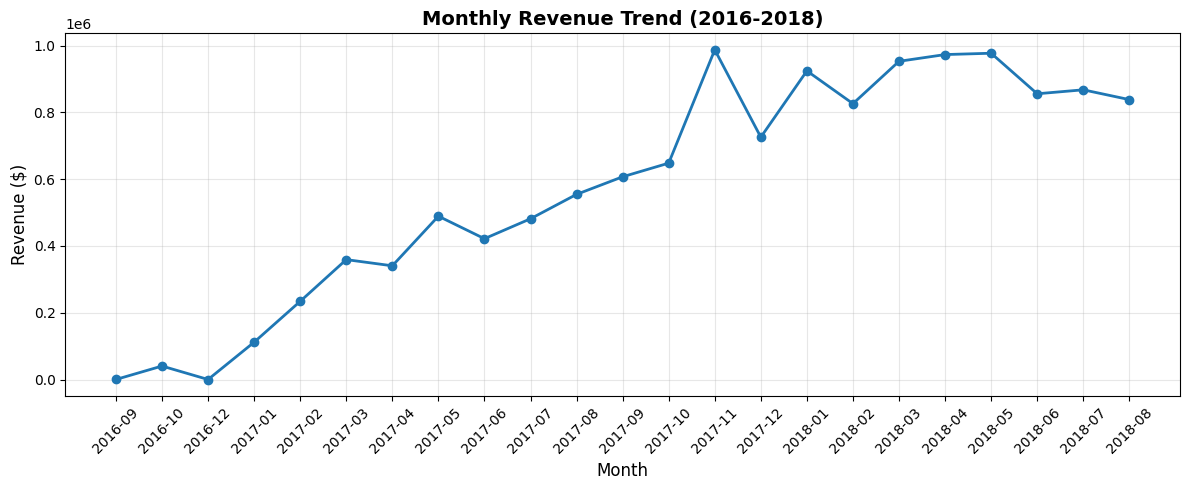

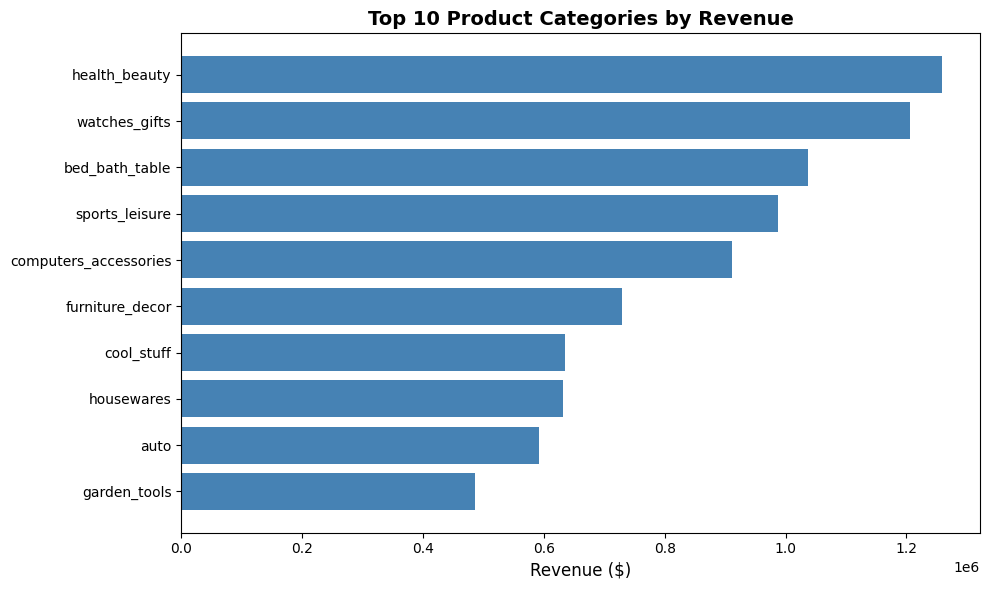

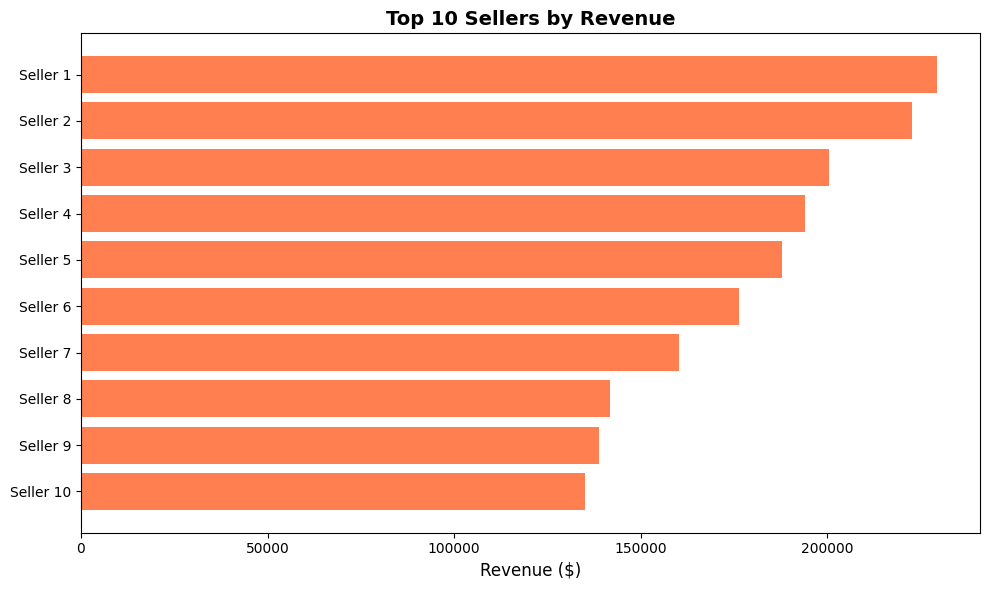

In [31]:
# Save charts for dashboard/reports folder
import os
os.makedirs('../dashboard', exist_ok=True)

# Re-create and save monthly revenue chart
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue['order_month'], monthly_revenue['price'], marker='o', linewidth=2, markersize=6)
plt.title('Monthly Revenue Trend (2016-2018)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../dashboard/monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
print("✓ Saved: monthly_revenue_trend.png")

# Re-create and save top categories chart
plt.figure(figsize=(10, 6))
plt.barh(top_categories['product_category_name_english'], top_categories['price'], color='steelblue')
plt.xlabel('Revenue ($)', fontsize=12)
plt.title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../dashboard/top_categories.png', dpi=150, bbox_inches='tight')
print("✓ Saved: top_categories.png")

# Re-create and save top sellers chart
plt.figure(figsize=(10, 6))
plt.barh(range(len(seller_revenue)), seller_revenue['revenue'], color='coral')
plt.yticks(range(len(seller_revenue)), [f"Seller {i+1}" for i in range(len(seller_revenue))])
plt.xlabel('Revenue ($)', fontsize=12)
plt.title('Top 10 Sellers by Revenue', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../dashboard/top_sellers.png', dpi=150, bbox_inches='tight')
print("✓ Saved: top_sellers.png")


## 6. Key Findings Summary

### Revenue Performance
- **Total Revenue**: $15.4M (products $13.2M + freight $2.2M)
- **Average Order Value**: $159.83
- **Delivery Success Rate**: 97% (96,478 delivered orders)
- **Revenue Trend**: Strong upward growth from 2016-2018

### Top Product Categories
1. Health & Beauty (highest revenue)
2. Watches & Gifts
3. Bed, Bath & Table
4. Sports & Leisure
5. Computers & Accessories

### Seller Performance
- Top seller: $229,472 revenue (1.7% of total)
- Top 10 sellers: ~$1.8M combined (~12% of total)
- Revenue well-distributed (no monopoly)

---

## 7. Business Recommendations

Based on this analysis, the e-commerce platform should:

1. **Invest in Health & Beauty**: This category drives the most revenue - expand product selection and marketing
2. **Maintain High Delivery Standards**: 97% success rate is excellent - continue focus on logistics
3. **Support Top Sellers**: Create partnership programs for high-revenue sellers
4. **Monitor Seasonal Trends**: Revenue shows peaks - optimize inventory and marketing for high seasons
5. **Focus on Growth Categories**: Watches, home goods, and sports are strong performers

---

## 8. Next Steps

- Build an interactive dashboard in Power BI or Tableau for real-time monitoring
- Conduct customer segmentation analysis to identify high-value customer groups
- Perform review sentiment analysis to correlate ratings with sales
- Build predictive models to forecast future sales trends
